In [ ]:
import pandas as pd
import numpy as np
import torch
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision import transforms
import torch.nn as nn
import torch.optim as optim

In [ ]:
epochs = 20

In [ ]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [ ]:
transform = transforms.Compose([
    transforms.Resize((28, 28)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

In [ ]:
dataset = datasets.MNIST(root="", download=True, transform=transform)

In [ ]:
dataloader = DataLoader(dataset, batch_size=64, shuffle=True)

In [ ]:
class Generator(nn.Module):
  def __init__(self, input_size=100, output_size=28*28):
    super().__init__()
    self.Model = nn.Sequential(

        nn.Linear(input_size,32),
        nn.ReLU(),

        nn.Linear(32,64),
        nn.ReLU(),

        nn.Linear(64,128),
        nn.ReLU(),

        nn.Linear(128,256),
        nn.ReLU(),

        nn.Linear(256,512),
        nn.ReLU(),

        nn.Linear(512,1024),
        nn.ReLU(),

        nn.Linear(1024,output_size),
        nn.Tanh()

    )
  def forward(self,x):
    return self.Model(x)


In [ ]:
class Discriminator(nn.Module):
  def __init__(self, img_size=28*28):
    super().__init__()
    self.Model = nn.Sequential(

        nn.Linear(img_size,32),
        nn.LeakyReLU(0.2),

        nn.Linear(32,64),
        nn.LeakyReLU(0.2),

        nn.Linear(64,128),
        nn.LeakyReLU(0.2),

        nn.Linear(128,1),
        nn.Sigmoid(),

    )
  def forward(self,img):
    img_flat = img.view(img.size(0), -1)
    return self.Model(img_flat)


In [ ]:
generator = Generator().to(device)
discriminator = Discriminator().to(device)

In [ ]:
criterion = nn.BCELoss()

In [ ]:
g_optimizer = optim.Adam(generator.parameters(), lr=0.0002, betas=(0.5, 0.999))
d_optimizer = optim.Adam(discriminator.parameters(), lr=0.00005, betas=(0.5, 0.999))

In [ ]:
for epoch in range(epochs):
  for real_img,_ in dataloader:
    real_img = real_img.to(device)
    batch_size_curr = real_img.size(0)

    real_labels = torch.full((batch_size_curr, 1),0.9).to(device)
    fake_labels = torch.full((batch_size_curr, 1),0.1).to(device)

    ##train discriminator##

    z = torch.randn(batch_size_curr,100).to(device)
    fake_img = generator(z)

    real_loss = criterion(discriminator(real_img),real_labels)
    fake_loss = criterion(discriminator(fake_img.detach()),fake_labels)

    d_loss = real_loss + fake_loss

    d_optimizer.zero_grad()
    d_loss.backward()
    d_optimizer.step()

    ##train generator##

    z = torch.randn(batch_size_curr,100).to(device)
    fake_img = generator(z)

    g_loss = criterion(discriminator(fake_img),real_labels)

    g_optimizer.zero_grad()
    g_loss.backward()
    g_optimizer.step()

  print(f"Epoch {epoch+1}/{epochs}, Discriminator Loss: {d_loss.item():.4f}, Generator Loss: {g_loss.item().4f}")

Epoch 1/20, Discriminator Loss: 1.389158844947815, Generator Loss: 0.6934320330619812
Epoch 2/20, Discriminator Loss: 1.3861393928527832, Generator Loss: 0.6937277317047119
Epoch 3/20, Discriminator Loss: 1.3872361183166504, Generator Loss: 0.691881537437439
Epoch 4/20, Discriminator Loss: 1.3873800039291382, Generator Loss: 0.6952763199806213
Epoch 5/20, Discriminator Loss: 1.3871185779571533, Generator Loss: 0.6993935108184814
Epoch 6/20, Discriminator Loss: 1.3881340026855469, Generator Loss: 0.6920121312141418
Epoch 7/20, Discriminator Loss: 1.3911583423614502, Generator Loss: 0.6984105110168457
Epoch 8/20, Discriminator Loss: 1.389439582824707, Generator Loss: 0.6813796162605286
Epoch 9/20, Discriminator Loss: 1.3851864337921143, Generator Loss: 0.7016578316688538
Epoch 10/20, Discriminator Loss: 1.3892382383346558, Generator Loss: 0.6954305171966553
Epoch 11/20, Discriminator Loss: 1.353187084197998, Generator Loss: 0.6962985992431641
Epoch 12/20, Discriminator Loss: 1.3657722473

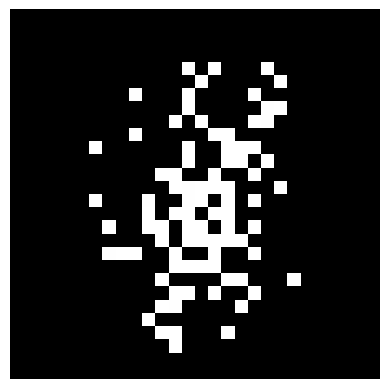

In [ ]:
import torch
import matplotlib.pyplot as plt
import torchvision

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

generator.to(device)
generator.eval()   # IMPORTANT for inference

# generate noise on same device
noise = torch.randn(1, 100, device=device)

with torch.no_grad():   # IMPORTANT (no gradients needed)
    fake = generator(noise)

# reshape safely
fake_images = fake.view(-1, 1, 28, 28).cpu()

# create grid (works even for batch size 1)
grid = torchvision.utils.make_grid(fake_images, nrow=1, normalize=True)

plt.imshow(grid.permute(1, 2, 0))
plt.axis("off")
plt.show()